In [1]:
#! pip install python-shogi 

In [2]:
import sys
print (sys.path)

['/mnt/c/Users/hmats/workspace/DeepLearningShogi/notebook', '/home/hmatsuya/anaconda3/lib/python38.zip', '/home/hmatsuya/anaconda3/lib/python3.8', '/home/hmatsuya/anaconda3/lib/python3.8/lib-dynload', '', '/home/hmatsuya/.local/lib/python3.8/site-packages', '/home/hmatsuya/anaconda3/lib/python3.8/site-packages', '/mnt/c/Users/hmats/workspace/Ayane', '/mnt/c/Users/hmats/workspace/Ayane/source', '/home/hmatsuya/anaconda3/lib/python3.8/site-packages/IPython/extensions', '/home/hmatsuya/.ipython']


In [3]:
import shogi
from shogi import CSA

In [4]:
from bs4 import BeautifulSoup

In [5]:
import requests

In [6]:
import io

In [7]:
from datetime import date, timedelta, datetime

In [8]:
import time

In [9]:
import re

In [10]:
import os

In [11]:
import pickle

In [12]:
import pandas

In [13]:
import cshogi

In [14]:
import numpy as np
import pandas as pd

## Set suffix

In [15]:
suffix = "20210428"

In [16]:
def get_eval(csa):
    values = []
    for m in re.finditer("'\*\*\s+(-?\d+)", csa, re.MULTILINE):
        values.append(int(m.group(1)))
        
#     return [values[0::2], values[1::2]]
    return values

In [17]:
def get_sfen_from_csa(csa):
    # Convert CSA to SFEN
    try:
        sfen = CSA.Parser.parse_str(csa)[0]
        sfen['csa'] = csa
        sfen['url'] = url
        sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
        sfen['values'] = get_eval(csa)
        sfen['toryo'] = (re.search("%TORYO|%KACHI", csa) != None)
#         print(sfen['values'])
#         print(len(sfen['moves']), len(sfen['values']), sfen['toryo'])
    
        return sfen
    except Exception as e:
#         print(csa)
        print("Error parsing record:" + url)
        print(type(e), e)
        return None

In [18]:
# def get_sfen(url):
#     # Download
#     csa_page = requests.get(url)
#     csa = csa_page.content.decode()

#     # Convert CSA to SFEN
#     try:
#         sfen = CSA.Parser.parse_str(csa)[0]
#         sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
#         return sfen
#     except:
#         print(csa)
#         return None
def get_sfen(url):
    # Download
    csa_page = requests.get(url)
    csa = csa_page.content.decode()

    # Convert CSA to SFEN
    try:
        sfen = CSA.Parser.parse_str(csa)[0]
        sfen['csa'] = csa
        sfen['url'] = url
        sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
        sfen['values'] = get_eval(csa)
        sfen['toryo'] = (re.search("%TORYO|%KACHI", csa) != None)
#         print(sfen['values'])
#         print(len(sfen['moves']), len(sfen['values']), sfen['toryo'])
    
        return sfen
    except Exception as e:
#         print(csa)
        print("Error parsing record:" + url)
        print(type(e), e)
        return None

In [27]:
# with open(f'dr_black{suffix}.sfen', 'w') as fb, open(f'dr_white{suffix}.sfen', 'w') as fw:
#     for csa_url in denryu_urls:
#         sfen = get_sfen(csa_url)
#         if sfen == None:
#             continue

#         # Write out
#         print(sfen['names'])
#         if 'suisho' == sfen['names'][0] and sfen['win'] == 'b':
#             fb.write(sfen['record'] + '\n')
#         if 'suisho' == sfen['names'][1] and sfen['win'] == 'w':
#             fw.write(sfen['record'] + '\n')


### Download Floodgate records

#### Download ratings

In [19]:
rating_page = requests.get('http://wdoor.c.u-tokyo.ac.jp/shogi/logs/LATEST/players-floodgate.html')

In [20]:
soup = BeautifulSoup(rating_page.content, 'html.parser')

In [21]:
names = soup.select('td.name a')
ratings =  soup.select('td.rate span')
print(len(names), len(ratings))
assert(len(names) == len(ratings))

engine_names = []

for i in range(len(names)):
    name = names[i].contents[0]
    try:
        rating = int(ratings[i].contents[0])
    except:
        rating = -9999
    if rating >= 3800:
        engine_names.append(name)
        print(name, rating)
        
# with open(f'engine_names{suffix}.pickle', 'wb') as f:
#     # Pickle the 'engine_names' using the highest protocol available.
#     pickle.dump(engine_names, f, pickle.HIGHEST_PROTOCOL)

538 538
Kristallweizen-kai_Ryzen 4733
Hinatsuru_Ai 4617
BURNING_BRIDGES 4565
BURNING_BRIDGE_210419 4565
FROZEN_BRIDGE 4514
LUNA 4486
Suisho3kai_TR3990X 4473
Marulk 4459
dlshogi_with_gct_065_v100x8 4458
BLUETRANSPARENCY 4431
Suisho4_TR3990X 4430
Hainaken_RyzenTR3990X 4407
Yashajin_Ai 4407
eques 4404
QueenAI_210222_i9-7920x 4401
gct_v100x8_model-0000195 4399
gcttest_x6_RTX2080ti 4398
AAV 4388
BURNING_BRIDGE_210404z 4379
Frozen 4378
Hainaken_Corei9-7980XE_18c 4370
xg_kpe9 4364
ECLIPSE_RyzenTR3990X 4357
BURNING_BRIDGE_210401 4334
nnue_Ryzen5-5600X 4309
xeon_w 4308
ANESIS 4308
xeon_gold 4307
EXTREME 4306
gct_model-0000214_a100x8 4297
xgs 4293
kame 4283
Mariel 4283
GlassPrison_Ryzen7-4800H 4276
fist 4270
Kristallweizen-TR2990WX 4270
NS03_EET 4269
daigo8 4263
tanukichi_3990X 4262
Karimero 4248
gcttest_x6_v3_RTX2080ti 4245
DG_test210419 4241
Stargazer 4237
RUN 4234
Cendrillon 4233
Sophia 4232
KASHMIR 4231
RINGO 4230
NEEDLED-35.8kai1361_Ryzen7-4800H 4223
TK045 4221
Kristffersen 4215
Procyon 421

#### Download records

In [22]:
fg_urls = []
for i in range(0, 365):
    time.sleep(0.1)
    d = date.today() - timedelta(days=i)
    
    # Download daily index page
    daily_url = ('http://wdoor.c.u-tokyo.ac.jp/shogi/x/' + 
                 str(d.year) +'/' + str(d.month).zfill(2) + '/' + str(d.day).zfill(2) + '/');
#     print(daily_url)
    daily_page = requests.get(daily_url)
    soup = BeautifulSoup(daily_page.content, 'html.parser')
#     print(daily_page)
    
    # Iterate over links
    links = soup.find_all('a')
    for link in links:
        href = link.attrs['href']
#         print(href)
        if '.csa' in href:
            _ = href.split('+')
            black_name = _[2]
            white_name = _[3]
            if black_name in engine_names and white_name in engine_names:   
                fg_urls.append(daily_url + href)
            
    print(str(d.year) +'/' + str(d.month).zfill(2) + '/' + str(d.day).zfill(2) + '/', len(fg_urls))

print(len(fg_urls))

2021/04/28/ 101
2021/04/27/ 208
2021/04/26/ 378
2021/04/25/ 527
2021/04/24/ 646
2021/04/23/ 746
2021/04/22/ 869
2021/04/21/ 1012
2021/04/20/ 1172
2021/04/19/ 1301
2021/04/18/ 1409
2021/04/17/ 1483
2021/04/16/ 1572
2021/04/15/ 1657
2021/04/14/ 1756
2021/04/13/ 1859
2021/04/12/ 1974
2021/04/11/ 2042
2021/04/10/ 2102
2021/04/09/ 2186
2021/04/08/ 2279
2021/04/07/ 2370
2021/04/06/ 2469
2021/04/05/ 2549
2021/04/04/ 2612
2021/04/03/ 2694
2021/04/02/ 2778
2021/04/01/ 2806
2021/03/31/ 2807
2021/03/30/ 2807
2021/03/29/ 2807
2021/03/28/ 2807
2021/03/27/ 2848
2021/03/26/ 2884
2021/03/25/ 2935
2021/03/24/ 2990
2021/03/23/ 3040
2021/03/22/ 3111
2021/03/21/ 3183
2021/03/20/ 3248
2021/03/19/ 3267
2021/03/18/ 3317
2021/03/17/ 3373
2021/03/16/ 3415
2021/03/15/ 3452
2021/03/14/ 3492
2021/03/13/ 3515
2021/03/12/ 3571
2021/03/11/ 3634
2021/03/10/ 3687
2021/03/09/ 3763
2021/03/08/ 3820
2021/03/07/ 3911
2021/03/06/ 3970
2021/03/05/ 4006
2021/03/04/ 4030
2021/03/03/ 4070
2021/03/02/ 4116
2021/03/01/ 4173
2021

In [23]:
game_count = 0; error_count = 0
sfens = []
for i, csa_url in enumerate(fg_urls):
    sfen = get_sfen(csa_url)
    if (sfen == None) or (not sfen['toryo']):
        # Could not parse CSA file
        error_count += 1
        time.sleep(0.001)
        continue
    sfens.append(sfen)
    game_count += 1
    if i % 100 == 0:
        print('.', end='', flush=True)
    time.sleep(0.001)


print("game_count:", game_count)
print("error_count:", error_count)

.......................Error parsing record:http://wdoor.c.u-tokyo.ac.jp/shogi/x/2021/03/27/wdoor+floodgate-300-10F+dlshogitest+DLSuishoFu6.02_RTX3090+20210327220009.csa
<class 'ValueError'> Invalid line 391:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
..............................................Error parsing record:http://wdoor.c.u-

In [14]:
import pickle

# save
# pickle.dump(sfens, open("sfens2.pkl", "wb"))
# pickle.dump(engine_names, open("engine_names2.pkl", "wb"))

# load
sfens = pickle.load(open("sfens2.pkl", "rb"))

In [89]:
game_count = 0; error_count = 0
def print_sfen(sfen):
    print(sfen['names'], sfen['win'], len(sfen['moves']))
#     print('position ' + sfen['record'] + '\n')
    
positions = []
moves = []
black = []
white = []
win = []
ply = []
turn = []

with open(f'fg_black{suffix}.sfen', 'w') as fb, open(f'fg_white{suffix}.sfen', 'w') as fw, open(f'fg_all{suffix}.sfen', 'w') as fa:
    board = cshogi.Board()

    for sfen in sfens:
        if (sfen == None) or (not sfen['toryo']):
            # Could not parse CSA file
            error_count += 1;
            continue

        if len(sfen["values"]) < 60:
            error_count += 1;
            time.sleep(1)
            continue
            
#         print(sfen["values"], flush=True)
            
        # Write out
#         print(sfen['names'])
#         if sfen['names'][0] in engine_names and sfen['win'] == 'b': # 5600 sfens

        fa.write(sfen['record'] + '\n')

        if sfen['win'] == 'b' and (min(sfen['values'][0::2]) > -60):
            fb.write(sfen['record'] + '\n')
            if sfen['names'][0] not in engine_names:
                print_sfen(sfen)
#         if sfen['names'][1] in engine_names and sfen['win'] == 'w':
        if sfen['win'] == 'w' and (max(sfen['values'][1::2]) < 120):
            fw.write(sfen['record'] + '\n')
            if sfen['names'][1] not in engine_names:
                print_sfen(sfen)
                
#         if game_count % 100 == 0:
#             print(datetime.now(), game_count)
        
    
        board = cshogi.Board()
        iply = 1
        
#         positions.append(board.sfen())
#         black.append(sfen['names'][0])
#         white.append(sfen['names'][1])
#         win.append(1.0 if sfen['win'] == board.turn else 0)
#         ply.append(iply)
#         turn.append(board.turn)
#         moves.append(sfen['moves'][iply - 1])

        for move in sfen['moves']:
            positions.append(board.sfen())
            black.append(sfen['names'][0])
            white.append(sfen['names'][1])
            temp_win = 0 if sfen['win'] == 'b' else 1
            win.append(1.0 if temp_win == board.turn else 0)
            ply.append(iply)
            turn.append(board.turn)
            moves.append(sfen['moves'][iply - 1])
            
            board.push_usi(move)
            iply += 1


        game_count += 1
        
print("game_count:", game_count);
print("error_count:", error_count);

game_count: 11587
error_count: 66


In [90]:
print(len(positions))
data = {
    'position': positions,
    'black': black,
    'white': white,
    'win': win,
    'ply': ply,
    'turn': turn,
    'move': moves,
}
position_df = pandas.DataFrame(data)
position_df

1859482


,position,black,white,win,ply,turn,move
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,1,0,2g2f
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,2,1,8c8d
2,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,3,0,2f2e
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,4,1,8d8e
4,lnsgkgsnl/1r5b1/p1ppppppp/9/1p5P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,5,0,7g7f
...,...,...,...,...,...,...,...
1859477,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP2N4/2K1pp1G1/...,mytest0426,Krist_483_473stb_16t_100m,1.0,148,1,B*6f
1859478,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/2K1pp1G1...,mytest0426,Krist_483_473stb_16t_100m,0.0,149,0,7g6h
1859479,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,1.0,150,1,G*5h
1859480,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,0.0,151,0,6h7i


In [16]:
import pickle

# save
# pickle.dump(position_df, open("position_df2.pkl", "wb"))

# load
position_df = pickle.load(open("position_df2.pkl", "rb"))

In [17]:
position_df

,position,black,white,win,ply,turn,move
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,1,0,2g2f
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,2,1,8c8d
2,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,3,0,2f2e
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,4,1,8d8e
4,lnsgkgsnl/1r5b1/p1ppppppp/9/1p5P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,5,0,7g7f
...,...,...,...,...,...,...,...
1859477,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP2N4/2K1pp1G1/...,mytest0426,Krist_483_473stb_16t_100m,1.0,148,1,B*6f
1859478,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/2K1pp1G1...,mytest0426,Krist_483_473stb_16t_100m,0.0,149,0,7g6h
1859479,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,1.0,150,1,G*5h
1859480,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,0.0,151,0,6h7i


In [18]:
nodup_pos = position_df.drop_duplicates(subset=['position', 'move', 'black', 'white', 'win'])
len(nodup_pos)

1788554

In [19]:
nodup_pos

,position,black,white,win,ply,turn,move
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,1,0,2g2f
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,2,1,8c8d
2,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,3,0,2f2e
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,1.0,4,1,8d8e
4,lnsgkgsnl/1r5b1/p1ppppppp/9/1p5P1/9/PPPPPPP1P/...,40b_n013_RTX3070,GCT_model-0000167_RTX3070,0.0,5,0,7g7f
...,...,...,...,...,...,...,...
1859477,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP2N4/2K1pp1G1/...,mytest0426,Krist_483_473stb_16t_100m,1.0,148,1,B*6f
1859478,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/2K1pp1G1...,mytest0426,Krist_483_473stb_16t_100m,0.0,149,0,7g6h
1859479,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,1.0,150,1,G*5h
1859480,l7S/4gl3/2np3+R1/p5p2/1pn+bk3p/PP1bN4/4pp1G1/2...,mytest0426,Krist_483_473stb_16t_100m,0.0,151,0,6h7i


In [20]:
agg = nodup_pos.groupby(['position', 'move']).agg(count=('win', 'count'), sum=('win', sum), mean=('win', np.mean))
agg

,,count,sum,mean
position,move,,,
+B+B1+L2n1l/3S+P2g1/1Pp2sn1p/Kp1Ppp1k1/P6s1/3S1P3/8+r/3G1gg2/L2N2+n+r1 w L8p 1,4c5b,1,1.0,1.0
+B+B1+L2n1l/3Sl2g1/1Pp1Psn1p/Kp1Ppp1k1/P6s1/3S1P3/8+r/3G1gg2/L2N2+n+r1 b 8p 1,5c5b+,1,0.0,0.0
+B+B1+L2n1l/3Sl2g1/1Pp1Psnkp/Kp1Ppp3/P6s1/3S1P3/8+r/3G1gg2/L2N2+n+r1 w 8p 1,2c2d,1,1.0,1.0
+B+B1+L2n1l/3Sl2g1/1Pp2snkp/Kp1Ppp3/P6s1/3S1P1+r1/8+r/3G1gg2/L2N2+n2 w P8p 1,2f2i,1,1.0,1.0
+B+B1+L2n1l/3Sl2g1/1Pp2snkp/Kp1Ppp3/P6s1/3S1P3/8+r/3G1gg2/L2N2+n+r1 b P8p 1,P*5c,1,0.0,0.0
...,...,...,...,...
spkg1n2l/p1s1+P+P3/1bgpp3p/7p1/6p2/4n2NP/PP1P+BLN2/1+pr2G3/L4K1RL b G2S2P2p 1,S*6b,1,1.0,1.0
spkg1n2l/p1s1+P+P3/1bgpp3p/7p1/6p2/7NP/PP1P+BLN2/1+pr2G3/L4K1RL w G2S2Pn2p 1,N*5f,1,0.0,0.0
spkg1n2l/p1s1+P1+P2/1bgpp3p/7p1/6p2/7NP/PP1P+BLN2/1+pr2G3/L4K1RL b G2S2Pn2p 1,3b4b,1,1.0,1.0


In [21]:
pos_count = nodup_pos.groupby(['position']).agg(pos_count = ('win', 'count'), pos_sum = ('win', sum), pos_mean = ('win', np.mean))
pos_count[pos_count['pos_count'] > 100]

,pos_count,pos_sum,pos_mean
position,,,
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/1PSPPSN2/2GK1G1R1/LN6L w Bb 1,146,69.0,0.472603
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/1PSPPSN2/2GK3R1/LN3G2L b Bb 1,126,70.0,0.555556
l6nl/1r1g1kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/1PSPPSN2/2GK1G1R1/LN6L b Bb 1,131,76.0,0.580153
ln1g2snl/1rs1k1gb1/p1ppppppp/9/1p5P1/P8/1PPPPPP1P/1BG3SR1/LNS1KG1NL b - 1,104,50.0,0.480769
ln1gk1snl/1rs3gb1/2ppppppp/p8/1p5P1/P8/1PPPPPP1P/1BG3SR1/LNS1KG1NL b - 1,226,141.0,0.623894
...,...,...,...
lnsgkgsnl/1r7/ppppp1bpp/5pp2/7P1/2P6/PP1PPPP1P/1B3S1R1/LNSGKG1NL w - 1,243,111.0,0.456790
lnsgkgsnl/1r7/ppppp1bpp/5pp2/7P1/2P6/PP1PPPP1P/1B5R1/LNSGKGSNL b - 1,335,187.0,0.558209
lnsgkgsnl/5r1b1/ppppp2pp/5pp2/9/2P4P1/PP1PPPP1P/1B3S1R1/LNSGKG1NL b - 1,115,64.0,0.556522


In [22]:
# agg_count = agg.merge(pos_count, how='left', on='position', validate='many_to_one')
agg_count = agg.join(pos_count, how='left', on='position')

agg_count[agg_count['pos_count'] > 30]
# agg_count.loc["ln1gk1snl/1rs3gb1/p1ppppppp/9/1p5P1/9/PPPPPPP1P/1BG3SR1/LNS1KG1NL b - 1"]
# agg_count.index
#agg_count.columns

count   sum  \
position                                           move                
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i      4   2.0   
                                                   5i5h      5   1.0   
                                                   5i6h     19  11.0   
                                                   6g6f      3   3.0   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b      3   1.0   
...                                                        ...   ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c      4   4.0   
                                                   6b6c      3   1.0   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e      3   0.0   
                                                   6h6i     34  15.0   
                                                   6h7i     64  34.0   

                                                             mean  pos_count  \
position                                           move                        
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i  0.500000         31   
                                                   5i5h  0.200000         31   
                                                   5i6h  0.578947         31   
                                                   6g6f  1.000000         31   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b  0.333333        146   
...                                                           ...        ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c  1.000000         69   
                                                   6b6c  0.333333         69   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e  0.000000        101   
                                                   6h6i  0.441176        101   
                                                   6h7i  0.531250        101   

                                                         pos_sum  pos_mean  
position                                           move                     
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i     17.0  0.548387  
                                                   5i5h     17.0  0.548387  
                                                   5i6h     17.0  0.548387  
                                                   6g6f     17.0  0.548387  
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b     69.0  0.472603  
...                                                          ...       ...  
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c     33.0  0.478261  
                                                   6b6c     33.0  0.478261  
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e     49.0  0.485149  
                                                   6h6i     49.0  0.485149  
                                                   6h7i     49.0  0.485149  

[2743 rows x 6 columns]

In [23]:
adj_n = 30
agg_count['adj_count'] = agg_count['count'] + adj_n
agg_count['adj_sum']    = agg_count['sum'] + (adj_n * agg_count['pos_mean'])
agg_count['adj_mean']   = agg_count['adj_sum'] /  agg_count['adj_count']
agg_count[agg_count['pos_count'] > 60]
# pos = "lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL w Bb 1"
# agg_count.loc[pos]

count   sum  \
position                                           move                
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b      3   1.0   
                                                   6a6b    118  49.0   
                                                   6a7b      8   7.0   
                                                   8b8a     17  12.0   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i     14  10.0   
...                                                        ...   ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c      4   4.0   
                                                   6b6c      3   1.0   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e      3   0.0   
                                                   6h6i     34  15.0   
                                                   6h7i     64  34.0   

                                                             mean  pos_count  \
position                                           move                        
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b  0.333333        146   
                                                   6a6b  0.415254        146   
                                                   6a7b  0.875000        146   
                                                   8b8a  0.705882        146   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i  0.714286        126   
...                                                           ...        ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c  1.000000         69   
                                                   6b6c  0.333333         69   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e  0.000000        101   
                                                   6h6i  0.441176        101   
                                                   6h7i  0.531250        101   

                                                         pos_sum  pos_mean  \
position                                           move                      
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b     69.0  0.472603   
                                                   6a6b     69.0  0.472603   
                                                   6a7b     69.0  0.472603   
                                                   8b8a     69.0  0.472603   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i     70.0  0.555556   
...                                                          ...       ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c     33.0  0.478261   
                                                   6b6c     33.0  0.478261   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e     49.0  0.485149   
                                                   6h6i     49.0  0.485149   
                                                   6h7i     49.0  0.485149   

                                                         adj_count    adj_sum  \
position                                           move                         
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b         33  15.178082   
                                                   6a6b        148  63.178082   
                                                   6a7b         38  21.178082   
                                                   8b8a         47  26.178082   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i         44  26.666667   
...                                                            ...        ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c         34  18.347826   
                                                   6b6c         33  15.347826   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e         33  14.554455   
                                                   6h6i         64  29.554455   
                                                   6h7i         94  48.554455   

          

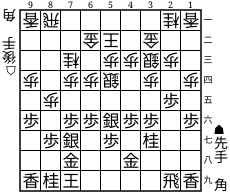

,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean
move,,,,,,,,,
4c4d,48,21.0,0.437500,69,33.0,0.478261,78,35.347826,0.453177
5b4b,13,7.0,0.538462,69,33.0,0.478261,43,21.347826,0.496461
5b6c,1,0.0,0.000000,69,33.0,0.478261,31,14.347826,0.462833
5d6c,4,4.0,1.000000,69,33.0,0.478261,34,18.347826,0.539642
6b6c,3,1.0,0.333333,69,33.0,0.478261,33,15.347826,0.465086


In [24]:
pos = "lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL w Bb 1"

board = cshogi.Board()
board.set_sfen(pos)
display(board.to_svg())

agg_count.loc[pos]

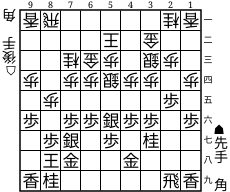

,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean
move,,,,,,,,,
2i5i,4,1.0,0.25,30,18.0,0.6,34,19.0,0.558824
2i7i,1,1.0,1.00,30,18.0,0.6,31,19.0,0.612903
4f4e,25,16.0,0.64,30,18.0,0.6,55,34.0,0.618182


In [25]:
pos = "lr5nl/4k1g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/1KG2G3/LN5RL b Bb 1"

board = cshogi.Board()
board.set_sfen(pos)
display(board.to_svg())

agg_count.loc[pos]

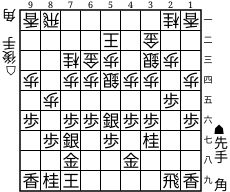

,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean
move,,,,,,,,,
5f6g,1,1.0,1.000000,18,10.0,0.555556,31,17.666667,0.569892
7i8h,17,9.0,0.529412,18,10.0,0.555556,47,25.666667,0.546099


In [26]:
pos = "lr5nl/4k1g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL b Bb 1"

board = cshogi.Board()
board.set_sfen(pos)
display(board.to_svg())

agg_count.loc[pos]

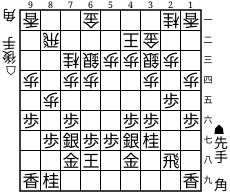

,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean
move,,,,,,,,,
6a5b,3,1.0,0.333333,146,69.0,0.472603,33,15.178082,0.459942
6a6b,118,49.0,0.415254,146,69.0,0.472603,148,63.178082,0.426879
6a7b,8,7.0,0.875000,146,69.0,0.472603,38,21.178082,0.557318
8b8a,17,12.0,0.705882,146,69.0,0.472603,47,26.178082,0.556980


In [27]:
pos = "l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/1PSPPSN2/2GK1G1R1/LN6L w Bb 1"

board = cshogi.Board()
board.set_sfen(pos)
display(board.to_svg())

agg_count.loc[pos]

## Chi-Squqre

In [28]:
from scipy.stats import chi2_contingency

def chisq(row):
    
    if row['count'] == row['pos_count']:
        return 9999
    
    if row['pos_sum'] == 0:
        return 8888
    
    if row['pos_sum'] == row['pos_count']:
        return 7777
    
#     display(row)

    other_sum   = row['pos_sum'] - row['sum']
    other_count = row['pos_count'] - row['count']
    
    table = [
        [row['sum'], row['count'] - row['sum']],
        [other_sum, other_count - other_sum]
    ]
    stat, p, dof, expected = chi2_contingency(table)
    return p

In [29]:
tmp_chisq = agg_count[agg_count['pos_count'] >= 3].apply(chisq, axis=1)
agg_chisq = agg_count[agg_count['pos_count'] >= 3].join(tmp_chisq.rename('p'), how='left', on=['position', 'move'])
agg_chisq

count  sum  \
position                                           move                
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a       2  0.0   
                                                   P*8g       1  0.0   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a       3  2.0   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g       1  1.0   
                                                   8h7g+      2  0.0   
...                                                         ...  ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e       2  0.0   
                                                   8a7b       1  0.0   
                                                   9d9e       1  0.0   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g       2  1.0   
                                                   L*2h       1  0.0   

                                                              mean  pos_count  \
position                                           move                         
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a   0.000000          3   
                                                   P*8g   0.000000          3   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a   0.666667          3   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g   1.000000          3   
                                                   8h7g+  0.000000          3   
...                                                            ...        ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e   0.000000          4   
                                                   8a7b   0.000000          4   
                                                   9d9e   0.000000          4   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g   0.500000          3   
                                                   L*2h   0.000000          3   

                                                          pos_sum  pos_mean  \
position                                           move                       
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a       0.0  0.000000   
                                                   P*8g       0.0  0.000000   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a       2.0  0.666667   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g       1.0  0.333333   
                                                   8h7g+      1.0  0.333333   
...                                                           ...       ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e       0.0  0.000000   
                                                   8a7b       0.0  0.000000   
                                                   9d9e       0.0  0.000000   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g       1.0  0.333333   
                                                   L*2h       1.0  0.333333   

                                                          adj_count  adj_sum  \
position                                           move                        
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a          32      0.0   
                                                   P*8g          31      0.0   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a          33     22.0   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g          31     11.0   
                                                   8h7g+         32     10.0   
...                                                             ...      ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e          32      0.0   
                                                   8a7b          31      0.0   
                                                   9d9e          31      0.0   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g          32     11.0   
                                                   L*2h          31     10.0   

In [30]:
agg_chisq[agg_chisq['pos_count'] >= 50]

count   sum  \
position                                           move                
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b      3   1.0   
                                                   6a6b    118  49.0   
                                                   6a7b      8   7.0   
                                                   8b8a     17  12.0   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i     14  10.0   
...                                                        ...   ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c      4   4.0   
                                                   6b6c      3   1.0   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e      3   0.0   
                                                   6h6i     34  15.0   
                                                   6h7i     64  34.0   

                                                             mean  pos_count  \
position                                           move                        
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b  0.333333        146   
                                                   6a6b  0.415254        146   
                                                   6a7b  0.875000        146   
                                                   8b8a  0.705882        146   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i  0.714286        126   
...                                                           ...        ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c  1.000000         69   
                                                   6b6c  0.333333         69   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e  0.000000        101   
                                                   6h6i  0.441176        101   
                                                   6h7i  0.531250        101   

                                                         pos_sum  pos_mean  \
position                                           move                      
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b     69.0  0.472603   
                                                   6a6b     69.0  0.472603   
                                                   6a7b     69.0  0.472603   
                                                   8b8a     69.0  0.472603   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i     70.0  0.555556   
...                                                          ...       ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c     33.0  0.478261   
                                                   6b6c     33.0  0.478261   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e     49.0  0.485149   
                                                   6h6i     49.0  0.485149   
                                                   6h7i     49.0  0.485149   

                                                         adj_count    adj_sum  \
position                                           move                         
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b         33  15.178082   
                                                   6a6b        148  63.178082   
                                                   6a7b         38  21.178082   
                                                   8b8a         47  26.178082   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 2h2i         44  26.666667   
...                                                            ...        ...   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 5d6c         34  18.347826   
                                                   6b6c         33  15.347826   
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P... 4f4e         33  14.554455   
                                                   6h6i         64  29.554455   
                                                   6h7i         94  48.554455   

          

In [31]:
# minimum p for position
minp = agg_chisq.groupby(['position']).agg(minp = ('p', min))
agg_minp = agg_chisq.join(minp, how='left', on=['position'])
agg_minp

count  sum  \
position                                           move                
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a       2  0.0   
                                                   P*8g       1  0.0   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a       3  2.0   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g       1  1.0   
                                                   8h7g+      2  0.0   
...                                                         ...  ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e       2  0.0   
                                                   8a7b       1  0.0   
                                                   9d9e       1  0.0   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g       2  1.0   
                                                   L*2h       1  0.0   

                                                              mean  pos_count  \
position                                           move                         
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a   0.000000          3   
                                                   P*8g   0.000000          3   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a   0.666667          3   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g   1.000000          3   
                                                   8h7g+  0.000000          3   
...                                                            ...        ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e   0.000000          4   
                                                   8a7b   0.000000          4   
                                                   9d9e   0.000000          4   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g   0.500000          3   
                                                   L*2h   0.000000          3   

                                                          pos_sum  pos_mean  \
position                                           move                       
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a       0.0  0.000000   
                                                   P*8g       0.0  0.000000   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a       2.0  0.666667   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g       1.0  0.333333   
                                                   8h7g+      1.0  0.333333   
...                                                           ...       ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e       0.0  0.000000   
                                                   8a7b       0.0  0.000000   
                                                   9d9e       0.0  0.000000   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g       1.0  0.333333   
                                                   L*2h       1.0  0.333333   

                                                          adj_count  adj_sum  \
position                                           move                        
+B2g2s1l/R1s1k1g2/p1nppp2p/2p3p2/2P6/Pp2S2RP/2N... 9a8a          32      0.0   
                                                   P*8g          31      0.0   
+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P... 9b9a          33     22.0   
+P2gk2nl/6gp1/3p1s2p/p1L1pppP1/3n5/P2B1SP1P/2NP... 8h7g          31     11.0   
                                                   8h7g+         32     10.0   
...                                                             ...      ...   
ls1g3nl/4ksg2/n1pppp2p/p4rpp1/P4N3/2P3P2/2BPPP2... 4d4e          32      0.0   
                                                   8a7b          31      0.0   
                                                   9d9e          31      0.0   
rn1g3nl/2s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1P2/... L*2g          32     11.0   
                                                   L*2h          31     10.0   

In [32]:
agg_minp[agg_minp['minp'] < 0.05]

count   sum  \
position                                           move                
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b      3   1.0   
                                                   6a6b    118  49.0   
                                                   6a7b      8   7.0   
                                                   8b8a     17  12.0   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b     10   6.0   
...                                                        ...   ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a      2   0.0   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c      5   2.0   
                                                   6b5b      2   1.0   
                                                   8a4a     11  10.0   
                                                   8a5a      1   0.0   

                                                             mean  pos_count  \
position                                           move                        
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b  0.333333        146   
                                                   6a6b  0.415254        146   
                                                   6a7b  0.875000        146   
                                                   8b8a  0.705882        146   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b  0.600000         29   
...                                                           ...        ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a  0.000000         70   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c  0.400000         19   
                                                   6b5b  0.500000         19   
                                                   8a4a  0.909091         19   
                                                   8a5a  0.000000         19   

                                                         pos_sum  pos_mean  \
position                                           move                      
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b     69.0  0.472603   
                                                   6a6b     69.0  0.472603   
                                                   6a7b     69.0  0.472603   
                                                   8b8a     69.0  0.472603   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b     15.0  0.517241   
...                                                          ...       ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a     34.0  0.485714   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c     13.0  0.684211   
                                                   6b5b     13.0  0.684211   
                                                   8a4a     13.0  0.684211   
                                                   8a5a     13.0  0.684211   

                                                         adj_count    adj_sum  \
position                                           move                         
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b         33  15.178082   
                                                   6a6b        148  63.178082   
                                                   6a7b         38  21.178082   
                                                   8b8a         47  26.178082   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b         40  21.517241   
...                                                            ...        ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a         32  14.571429   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c         35  22.526316   
                                                   6b5b         32  21.526316   
                                                   8a4a         41  30.526316   
                                                   8a5a         31  20.526316   

          

In [33]:
# Add flag
def pflag(row):
    if row['mean'] > row['pos_mean'] and row['p'] < 0.4:
        return '+'
    if row['mean'] < row['pos_mean'] and row['p'] < 0.4:
        return '-'
    return ''

agg_minp['pflag'] = agg_minp.apply(pflag, axis=1)
agg_minp[agg_minp['minp'] < 0.05]

count   sum  \
position                                           move                
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b      3   1.0   
                                                   6a6b    118  49.0   
                                                   6a7b      8   7.0   
                                                   8b8a     17  12.0   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b     10   6.0   
...                                                        ...   ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a      2   0.0   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c      5   2.0   
                                                   6b5b      2   1.0   
                                                   8a4a     11  10.0   
                                                   8a5a      1   0.0   

                                                             mean  pos_count  \
position                                           move                        
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b  0.333333        146   
                                                   6a6b  0.415254        146   
                                                   6a7b  0.875000        146   
                                                   8b8a  0.705882        146   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b  0.600000         29   
...                                                           ...        ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a  0.000000         70   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c  0.400000         19   
                                                   6b5b  0.500000         19   
                                                   8a4a  0.909091         19   
                                                   8a5a  0.000000         19   

                                                         pos_sum  pos_mean  \
position                                           move                      
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b     69.0  0.472603   
                                                   6a6b     69.0  0.472603   
                                                   6a7b     69.0  0.472603   
                                                   8b8a     69.0  0.472603   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b     15.0  0.517241   
...                                                          ...       ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a     34.0  0.485714   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c     13.0  0.684211   
                                                   6b5b     13.0  0.684211   
                                                   8a4a     13.0  0.684211   
                                                   8a5a     13.0  0.684211   

                                                         adj_count    adj_sum  \
position                                           move                         
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p5P1/P1P2PP1P/... 6a5b         33  15.178082   
                                                   6a6b        148  63.178082   
                                                   6a7b         38  21.178082   
                                                   8b8a         47  26.178082   
l2g3nl/1r3kg2/2nsppsp1/p1pp2p1p/1p7/P1P2PPPP/1P... 6a6b         40  21.517241   
...                                                            ...        ...   
lr5nl/3g1kg2/2nsppsp1/p1pp2p1p/1p7/P1PPSPPPP/1P... 8a4a         32  14.571429   
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/... 5d4c         35  22.526316   
                                                   6b5b         32  21.526316   
                                                   8a4a         41  30.526316   
                                                   8a5a         31  20.526316   

          

In [34]:
import dtale
import dtale.app as dtale_app

dtale_app.JUPYTER_SERVER_PROXY = False

d = dtale.show(agg_minp, host='localhost')
d._main_url

'http://localhost:40000/dtale/main/1'

/home/hmatsuya/anaconda3/lib/python3.8/site-packages/scipy/stats/morestats.py:1681: UserWarning:

p-value may not be accurate for N > 5000.



In [79]:
# bad moves
bad_moves = agg_minp[(agg_minp['pflag'] == '-') & (agg_minp['mean'] < 0.5) & (agg_minp['count'] >= 2)]
bad_moves

,,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean,p,minp,pflag
position,move,,,,,,,,,,,,
l1kg3nl/2s1gr3/2n1p2pp/1pppsbp2/p4p1P1/2PPP1P2/PP1GSP2P/LS4R2/KN1GB2NL b - 1,6i7i,3,0.0,0.00,6,2.0,0.333333,33,10.000000,0.303030,0.386476,0.386476,-
l1sg3nl/2k1gr1b1/1pn1ps1pp/p1pp1pp2/9/P1PPP2P1/1PB1SPP1P/1K2G2R1/LNSG3NL b - 1,7g8f,2,0.0,0.00,9,5.0,0.555556,32,16.666667,0.520833,0.324102,0.235680,-
l1sgkgsnl/1r5b1/p1nppp1pp/2p3p2/1p5P1/2P6/PPSPPPP1P/1B5R1/LN1GKGSNL b - 1,6g6f,2,0.0,0.00,22,12.0,0.545455,32,16.363636,0.511364,0.378803,0.378803,-
l1sgkgsnl/1r5b1/p1nppp1pp/2p3p2/1p7/2P4P1/PPSPPPP1P/3B3R1/LN1GKGSNL w - 1,6c6d,2,0.0,0.00,4,2.0,0.500000,32,15.000000,0.468750,0.317311,0.317311,-
l1sgkgsnl/1r7/p1npppbpp/2p3p2/1p5P1/2P6/PPSPPPP1P/1BG4R1/LN2KGSNL b - 1,6g6f,2,0.0,0.00,20,11.0,0.550000,32,16.500000,0.515625,0.368688,0.368688,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P/1PS1P1N2/2GK1G3/LN5RL b Bb 1,4f4e,3,0.0,0.00,101,49.0,0.485149,33,14.554455,0.441044,0.262498,0.262498,-
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/1KG2G1R1/LN6L b Bb 1,2h2i,4,1.0,0.25,14,9.0,0.642857,34,20.285714,0.596639,0.185877,0.134481,-
lr5nl/3k2g2/2ngp1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/1KG2G3/LN5RL w Bb 1,5d4c,5,2.0,0.40,19,13.0,0.684211,35,22.526316,0.643609,0.301918,0.048500,-


In [80]:
# very good moves
overriding_moves = agg_minp[(agg_minp['pflag'] == '+') & (agg_minp['minp'] < 0.3) & (agg_minp['sum'] >= 3)]
overriding_moves

,,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean,p,minp,pflag
position,move,,,,,,,,,,,,
l1r4nl/3gk1g2/2n1p1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL b Bb 1,7i8h,4,3.0,0.750000,13,5.0,0.384615,34,14.538462,0.427602,0.234958,0.234958,+
l1sg3nl/2k1gr1b1/1pn1ps1pp/p1pp1pp2/9/P1PPP2P1/1PB1SPP1P/1K2G2R1/LNSG3NL b - 1,9i9h,3,3.0,1.000000,9,5.0,0.555556,33,19.666667,0.595960,0.235680,0.235680,+
l1sgkgsnl/1r5b1/p1nppp1pp/1pp3p2/9/2P4P1/PPSPPPP1P/1B5R1/LN1GKGSNL b - 1,6i7h,5,4.0,0.800000,16,7.0,0.437500,35,17.125000,0.489286,0.153576,0.153576,+
l2g2knl/1r4g2/p1npppsp1/2ps2p1p/1p7/P1PP1PPPP/1PS1PS3/2GR2G2/LN2K2NL b Bb 1,9f9e,3,3.0,1.000000,8,5.0,0.625000,33,21.750000,0.659091,0.345779,0.144127,+
l2g3nl/1r1s1kg2/2n1ppsp1/p1pp2p1p/1p7/P1P2PPPP/1PSPPSN2/2G2G1R1/LN2K3L b Bb 1,2h2i,4,4.0,1.000000,7,5.0,0.714286,34,25.428571,0.747899,0.277102,0.277102,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
lr5nl/3gk1g2/2n1p1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/1KG2G3/LN3R2L b Bb 1,4i6i,6,4.0,0.666667,12,5.0,0.416667,36,16.500000,0.458333,0.241567,0.241567,+
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL w Bb 1,5d6c,4,4.0,1.000000,69,33.0,0.478261,34,18.347826,0.539642,0.101713,0.101713,+
lr5nl/3gk1g2/2n1ppsp1/p1pps1p1p/1p5P1/P1PPSPP1P/1PS1P1N2/2GK1G3/LN5RL b Bb 1,6h7i,64,34.0,0.531250,101,49.0,0.485149,94,48.554455,0.516537,0.311243,0.262498,+


In [81]:
# only-moves to add (only moves)
# only_moves = agg_minp.reset_index().join(nodup_pos, how='left', on=['position', 'move'])
# (agg_minp.reset_index()['position'].apply(lambda x: x.split(' ', 2)[1] == 'b'))
# (agg_minp['count'] == agg_minp['pos_count'])
tmp = agg_minp.reset_index()
only_moves = tmp[(tmp['count'] == tmp['pos_count']) & (((tmp.reset_index()['position'].apply(lambda x: x.split(' ', 2)[1] == 'b')) & (tmp['mean'] >= 0.55)) | ((tmp.reset_index()['position'].apply(lambda x: x.split(' ', 2)[1] == 'w')) & (tmp['mean'] >= 0.45)))]
only_moves['position'].apply(lambda x: x.split(' ', 1)[1])
only_moves

,position,move,count,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,adj_mean,p,minp,pflag
2,+Bn1g3nl/r1s1k1gs1/2pppp3/p5pbp/9/PPP2P2P/3PP1...,9b9a,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
6,+P2gk2nl/6gp1/3p1s2p/p1r1pppP1/2Ln5/P2B1SP1P/2...,7e7d,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
7,+P2gk2nl/6gp1/3p1s2p/p1r1pppP1/3n5/P2B1SP1P/1s...,L*7e,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
9,+P2gk2nl/6gp1/3p1s2p/p1r1pppP1/3n5/Ps1B1SP1P/1...,7h8g,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
10,+P2gk2nl/6gp1/3p1s2p/p1r1pppP1/3n5/Ps1B1SP1P/2...,8i7g,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39822,lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSP...,P*4g,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
39824,lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSP...,2i3i,3,2.0,0.666667,3,2.0,0.666667,33,22.0,0.666667,9999.0,9999.0,
39839,lr6l/3kg1g2/2ns1p1p1/p1pppsp1p/1p7/P1PPSPP1P/1...,7i8h,3,3.0,1.000000,3,3.0,1.000000,33,33.0,1.000000,9999.0,9999.0,
39847,lr6l/4g1gk1/+P2sp1np1/8p/2Pp1S1P1/1p2P3P/1P1P2...,N*3d,4,4.0,1.000000,4,4.0,1.000000,34,34.0,1.000000,9999.0,9999.0,


In [72]:
d2 = dtale.show(only_moves, host='localhost')
d2._main_url

'http://localhost:40000/dtale/main/2'

## Merge book files

In [152]:
os.getcwd()

'/mnt/c/Users/hmats/workspace/DeepLearningShogi/notebook'

In [153]:
# read csv
bestmoves = pd.read_csv('../x64/Release/bestmoves.csv', names=['idx', 'count', 'position', 'move'])
bestmoves = bestmoves.set_index(['position', 'move'])
bestmoves

,,idx,count
position,move,,
lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R1/LNSGKGSNL b - 1,2g2f,0,3709
lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 1,8c8d,1,2113
lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1,8c8d,2,1984
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL b - 1,2g2f,3,1572
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1,7g7f,4,1472
...,...,...,...
ln1gk2nl/1r4gb1/p2pss1pp/2p1ppp2/1p7/2P2PP2/PPBPPSNPP/2GS1R3/LNK2G2L w - 1,5c6d,4366,5
ln1gk1snl/1r7/p2pppgpp/2ps2p2/1p5P1/2P2P3/PPSPP1P1P/2G2S1R1/LN2KG1NL b Bb 1,4h4g,4367,5
ln1gkg1nl/1rs3s2/p1p1pp1pp/3p2p2/1p6P/2P6/PPGPPPPP1/1R3K3/LNS2GSNL w Bb 1,5a4b,4368,5


In [154]:
# Remove bad moves

# create index list
bad_index = zip(bad_moves.reset_index()['position'].tolist(), bad_moves.reset_index()['move'].tolist())
list(bad_index)

# drop
no_bad_moves = bestmoves[~bestmoves.index.isin(list(bad_index))]
len(no_bad_moves)


4371

In [155]:
# Override with very good moves
# Add very good moves
added_very_good = no_bad_moves.join(overriding_moves, how='outer', on=['position', 'move'], rsuffix='_override')
added_very_good['pflag'].value_counts(dropna=False)

NaN    4371
+       574
Name: pflag, dtype: int64

In [156]:
# Add only moves

merged = added_very_good.join(only_moves.set_index(['position', 'move']), how='outer', on=['position', 'move'], rsuffix='_only')
merged['pflag'].value_counts(dropna=False)

NaN    9216
+       574
Name: pflag, dtype: int64

In [157]:
merged

,,idx,count,count_override,sum,mean,pos_count,pos_sum,pos_mean,adj_count,adj_sum,...,mean_only,pos_count_only,pos_sum_only,pos_mean_only,adj_count_only,adj_sum_only,adj_mean_only,p_only,minp_only,pflag_only
position,move,,,,,,,,,,,,,,,,,,,,,
lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R1/LNSGKGSNL b - 1,2g2f,0.0,3709.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 1,8c8d,1.0,2113.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1,8c8d,2.0,1984.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL b - 1,2g2f,3.0,1572.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1,7g7f,4.0,1472.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSPP4/2GK2S2/LN3G1RL b B3P2p 1,P*4g,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.666667,3.0,2.0,0.666667,33.0,22.0,0.666667,9999.0,9999.0,
lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSPPP3/2GK2Sp1/LN3G1RL b B2Pp 1,2i3i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.666667,3.0,2.0,0.666667,33.0,22.0,0.666667,9999.0,9999.0,
lr6l/3kg1g2/2ns1p1p1/p1pppsp1p/1p7/P1PPSPP1P/1PS1P4/2G2G3/LNK4RL b BNPbn 1,7i8h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,3.0,3.0,1.000000,33.0,33.0,1.000000,9999.0,9999.0,


In [160]:
# remove duplicates
merged_nodup = merged.reset_index().drop_duplicates(subset=['position', 'move'])
merged_nodup

,position,move,idx,count,count_override,sum,mean,pos_count,pos_sum,pos_mean,...,mean_only,pos_count_only,pos_sum_only,pos_mean_only,adj_count_only,adj_sum_only,adj_mean_only,p_only,minp_only,pflag_only
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5...,2g2f,0.0,3709.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1...,8c8d,1.0,2113.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1...,8c8d,2.0,1984.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP...,2g2f,3.0,1572.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P...,7g7f,4.0,1472.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9785,lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSP...,P*4g,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.666667,3.0,2.0,0.666667,33.0,22.0,0.666667,9999.0,9999.0,
9786,lr6l/3g1kgs1/p1nsppn2/2pp4p/1p3N3/P1P2b2P/1PSP...,2i3i,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.666667,3.0,2.0,0.666667,33.0,22.0,0.666667,9999.0,9999.0,
9787,lr6l/3kg1g2/2ns1p1p1/p1pppsp1p/1p7/P1PPSPP1P/1...,7i8h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,3.0,3.0,1.000000,33.0,33.0,1.000000,9999.0,9999.0,
9788,lr6l/4g1gk1/+P2sp1np1/8p/2Pp1S1P1/1p2P3P/1P1P2...,N*3d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,4.0,4.0,1.000000,34.0,34.0,1.000000,9999.0,9999.0,


In [75]:
# Write out in YaneuraOu format

In [161]:
with open('user_book1.db', 'w') as f:
    for i, row in merged_nodup.iterrows():
#         print(i, row)
        f.write(f'sfen {row["position"].strip()}\n{row["move"].strip()} none 0 32 3\n')
    

#### Prune Merged UCB Book

In [ ]:
! (cd ../exe && python3 prune_book.py --help)

In [ ]:
# ! (cd ../exe && python3 prune_book.py uct_book_merged.pruned1000 --help)

#### Merge UCB and Flood gate books

In [ ]:
# makebook merge yaneura_book1.db yaneura_book2.db yaneura_book3.db
! (cd ../exe && ./YaneuraOu-by-gcc makebook merge ../notebook/floodgate.db uct_book_merged.pruned1000 ../notebook/floodgate-uct.db , quit)

In [ ]:
! (cd ../notebook && ln -s floodgate.db user_book1.db)
! (cd ../notebook && ln -s floodgate-uct.db user_book2.db)

## Edit book with huristics

In [ ]:
huristics = {
    # 76
    "sfen lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 2": "8c8d",
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1BG4R1/LNS1KGSNL w - 4": "8d8e",
    # 26
    "sfen lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 2": "8c8d",
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/1B5R1/LNSGKGSNL w - 4": "8d8e",
    # 26 <-> 76
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL w - 4": "8d8e",
    "sfen lnsgk1snl/1r4gb1/p1ppppppp/9/1p5P1/2P6/PP1PPPP1P/1BG4R1/LNS1KGSNL w - 8": "8e8f",
    "sfen lnsgkgsnl/1r5b1/p1pppp1pp/6p2/1p5P1/2P6/PP1PPPP1P/1BG4R1/LNS1KGSNL w - 8": "4a3b",
}

In [ ]:
with open('floodgate-uct.db') as infile, open('floodgate-uct-edited.db', 'w') as outfile:
    line = infile.readline()
    while(line):
        if line.strip() in huristics.keys():
            outfile.write(line)
            
            move = huristics[line.strip()]
            for line in infile:
                if line.startswith('sfen '):
                    break
                if line.startswith(move) or line.startswith('#'):
                    outfile.write(line)
                else:
                    outfile.write('# ' + line)
        else:
            outfile.write(line)
            line = infile.readline()


## Make book from csa records in a directory

In [ ]:
indir = 'records_for_book'
outfile_name = 'makebook_think.sfen'
with open(outfile_name, 'w') as outfile:
    for filename in os.listdir(indir):
        if filename.endswith(".csa"):
            print(os.path.join(directory, filename))
            csa = open('very_Important.txt', 'r').read()
            sfen = get_sfen_from_csa(csa)
            print(sfen)
            outfile.write(sfen + '\n')
        else:
            continue